In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

In [3]:
for col in ['Area', 'Perimeter']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

df.to_csv("Dry_Bean_Missing_Example.csv", index=False)

In [4]:
print(df.isnull().sum())

Area               681
Perimeter          681
MajorAxisLength      0
MinorAxisLength      0
AspectRation         0
Eccentricity         0
ConvexArea           0
EquivDiameter        0
Extent               0
Solidity             0
roundness            0
Compactness          0
ShapeFactor1         0
ShapeFactor2         0
ShapeFactor3         0
ShapeFactor4         0
Class                0
dtype: int64


# Bölüm 1: Veri Ön İşleme (Preprocessing)

In [5]:
df.loc[df.sample(frac=0.35, random_state=42).index, 'MajorAxisLength'] = np.nan


In [6]:
print(df.isnull().sum())


Area                681
Perimeter           681
MajorAxisLength    4764
MinorAxisLength       0
AspectRation          0
Eccentricity          0
ConvexArea            0
EquivDiameter         0
Extent                0
Solidity              0
roundness             0
Compactness           0
ShapeFactor1          0
ShapeFactor2          0
ShapeFactor3          0
ShapeFactor4          0
Class                 0
dtype: int64


In [7]:
df['Area'].fillna(df['Area'].median(), inplace=True)

C:\Users\serve\AppData\Local\Temp\ipykernel_9564\3191736679.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Area'].fillna(df['Area'].median(), inplace=True)


In [8]:
df['Perimeter'].fillna(df['Perimeter'].median(), inplace=True)

C:\Users\serve\AppData\Local\Temp\ipykernel_9564\2970744278.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Perimeter'].fillna(df['Perimeter'].median(), inplace=True)


In [9]:
print(df.isnull().sum())


Area                  0
Perimeter             0
MajorAxisLength    4764
MinorAxisLength       0
AspectRation          0
Eccentricity          0
ConvexArea            0
EquivDiameter         0
Extent                0
Solidity              0
roundness             0
Compactness           0
ShapeFactor1          0
ShapeFactor2          0
ShapeFactor3          0
ShapeFactor4          0
Class                 0
dtype: int64


In [10]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,NaN,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,NaN,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [11]:
df.drop(columns=["MajorAxisLength"], inplace=True)

# Sütun bazlı silme bu durumda daha mantıklı, çünkü:

# Sadece 1 sütunu kaybederiz

# Diğer tüm özellikler elimizde kalır

# Satır sayısını korumuş oluruz

In [12]:
print(df.isnull().sum().sum())  


0


In [13]:
print(df.head())

      Area  Perimeter  MinorAxisLength  AspectRation  Eccentricity  \
0  28395.0    610.291       173.888747      1.197191      0.549812   
1  28734.0    638.018       182.734419      1.097356      0.411785   
2  29380.0    624.110       175.931143      1.209713      0.562727   
3  30008.0    645.884       182.516516      1.153638      0.498616   
4  30140.0    620.134       190.279279      1.060798      0.333680   

   ConvexArea  EquivDiameter    Extent  Solidity  roundness  Compactness  \
0       28715     190.141097  0.763923  0.988856   0.958027     0.913358   
1       29172     191.272750  0.783968  0.984986   0.887034     0.953861   
2       29690     193.410904  0.778113  0.989559   0.947849     0.908774   
3       30724     195.467062  0.782681  0.976696   0.903936     0.928329   
4       30417     195.896503  0.773098  0.990893   0.984877     0.970516   

   ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0      0.007332      0.003147      0.834222      0.9987

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MinorAxisLength  13611 non-null  float64
 3   AspectRation     13611 non-null  float64
 4   Eccentricity     13611 non-null  float64
 5   ConvexArea       13611 non-null  int64  
 6   EquivDiameter    13611 non-null  float64
 7   Extent           13611 non-null  float64
 8   Solidity         13611 non-null  float64
 9   roundness        13611 non-null  float64
 10  Compactness      13611 non-null  float64
 11  ShapeFactor1     13611 non-null  float64
 12  ShapeFactor2     13611 non-null  float64
 13  ShapeFactor3     13611 non-null  float64
 14  ShapeFactor4     13611 non-null  float64
 15  Class            13611 non-null  object 
dtypes: float64(14), int64(1), object(1)
memory usage: 1.7+ MB


In [17]:
# Sayısal sütunları seçelim (sınıf etiketi hariç)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Area', 'Perimeter', 'MinorAxisLength', 'AspectRation', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness',
       'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3',
       'ShapeFactor4'],
      dtype='object')


In [18]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

In [19]:
print(IQR)

Area               23116.500000
Perimeter            258.019500
MinorAxisLength       41.183571
AspectRation           0.274802
Eccentricity           0.094538
ConvexArea         25579.500000
EquivDiameter         64.378463
Extent                 0.068218
Solidity               0.004343
roundness              0.084773
Compactness            0.071801
ShapeFactor1           0.001372
ShapeFactor2           0.001017
ShapeFactor3           0.114648
ShapeFactor4           0.004180
dtype: float64


In [20]:
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))

In [21]:
outliers

,Area,Perimeter,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13607,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13608,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13609,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
print(outliers.sum())


Area               562
Perimeter          486
MinorAxisLength    569
AspectRation       473
Eccentricity       843
ConvexArea         550
EquivDiameter      526
Extent             275
Solidity           778
roundness           91
Compactness        109
ShapeFactor1       533
ShapeFactor2         0
ShapeFactor3       195
ShapeFactor4       767
dtype: int64


In [23]:
# Aykırı değerleri silmemize gerek yok.

# Sınırlandırmaya da gerek yok.

# Aykırı değerler veri setine doğallık katıyor ve modelin genelleme kapasitesine zarar vermez.

Neden Özellik Ölçekleme Yapıyoruz?
Makine öğrenmesi algoritmalarının bazıları (özellikle:

Logistic Regression,

KNN,

SVM,

PCA,

LDA) gibi yöntemler, özelliklerin büyüklüklerinden etkilenir.
Örneğin, Area 20.000-30.000 aralığında iken, roundness 0.5-0.9 arasında olabiliyor.
Bu dengesizlik algoritmanın yanlış öğrenmesine neden olabilir.

Ölçekleme yaparak:

Modelin daha hızlı öğrenmesini sağlarız (özellikle gradient descent yöntemlerinde)

Daha doğru sonuçlar alırız

Özellikler eşit ağırlıklı hale gelir (örneğin PCA ve LDA için özellikle önemli!)

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
# Sadece sayısal sütunları ölçekleyeceğiz (Class hariç)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [27]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [28]:
print(df.head())


       Area  Perimeter  MinorAxisLength  AspectRation  Eccentricity  \
0 -0.844140  -1.159834        -0.631153     -1.565053     -2.185720   
1 -0.832339  -1.026990        -0.434445     -1.969784     -3.686040   
2 -0.809852  -1.093625        -0.585735     -1.514291     -2.045336   
3 -0.787991  -0.989302        -0.439290     -1.741618     -2.742211   
4 -0.783397  -1.112674        -0.266663     -2.117993     -4.535028   

   ConvexArea  EquivDiameter    Extent  Solidity  roundness  Compactness  \
0   -0.841451      -1.063341  0.289087  0.367613   1.423867     1.839116   
1   -0.826102      -1.044217  0.697477 -0.462907   0.231054     2.495449   
2   -0.808704      -1.008084  0.578195  0.518417   1.252865     1.764843   
3   -0.773975      -0.973337  0.671260 -2.241767   0.515049     2.081715   
4   -0.784286      -0.966080  0.476020  0.804772   1.874992     2.765330   

   ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0      0.680786      2.402173      1.925723      

Veri eksiklerini doldurduk

Aykırı değerleri analiz ettik 

Sayısal verileri StandardScaler ile normalize ettik

In [30]:
df["Class"].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
le = LabelEncoder()


In [33]:
df['Class'] = le.fit_transform(df['Class'])


In [34]:
print(df.head())


       Area  Perimeter  MinorAxisLength  AspectRation  Eccentricity  \
0 -0.844140  -1.159834        -0.631153     -1.565053     -2.185720   
1 -0.832339  -1.026990        -0.434445     -1.969784     -3.686040   
2 -0.809852  -1.093625        -0.585735     -1.514291     -2.045336   
3 -0.787991  -0.989302        -0.439290     -1.741618     -2.742211   
4 -0.783397  -1.112674        -0.266663     -2.117993     -4.535028   

   ConvexArea  EquivDiameter    Extent  Solidity  roundness  Compactness  \
0   -0.841451      -1.063341  0.289087  0.367613   1.423867     1.839116   
1   -0.826102      -1.044217  0.697477 -0.462907   0.231054     2.495449   
2   -0.808704      -1.008084  0.578195  0.518417   1.252865     1.764843   
3   -0.773975      -0.973337  0.671260 -2.241767   0.515049     2.081715   
4   -0.784286      -0.966080  0.476020  0.804772   1.874992     2.765330   

   ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0      0.680786      2.402173      1.925723      

In [35]:

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


# Bölüm 2: Özellik Seçimi ve Boyut İndirgeme

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [37]:
X = df.drop(columns=['Class'])
y = df['Class']

In [38]:
pca = PCA()
X_pca = pca.fit_transform(X)

In [39]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratios:", explained_variance)
print("Ortalama Explained Variance:", explained_variance.mean())

Explained Variance Ratios: [5.25003578e-01 2.77029713e-01 8.46871147e-02 5.45280244e-02
 2.92552277e-02 1.27901908e-02 7.48771467e-03 3.46603881e-03
 3.31011897e-03 1.87671101e-03 4.31898331e-04 7.85490227e-05
 5.14186052e-05 3.56407195e-06 1.38303983e-07]
Ortalama Explained Variance: 0.06666666666666667


In [40]:
mean_variance = explained_variance.mean()
selected_components = np.sum(explained_variance > mean_variance)
print("Seçilecek PCA bileşeni sayısı:", selected_components)

Seçilecek PCA bileşeni sayısı: 3


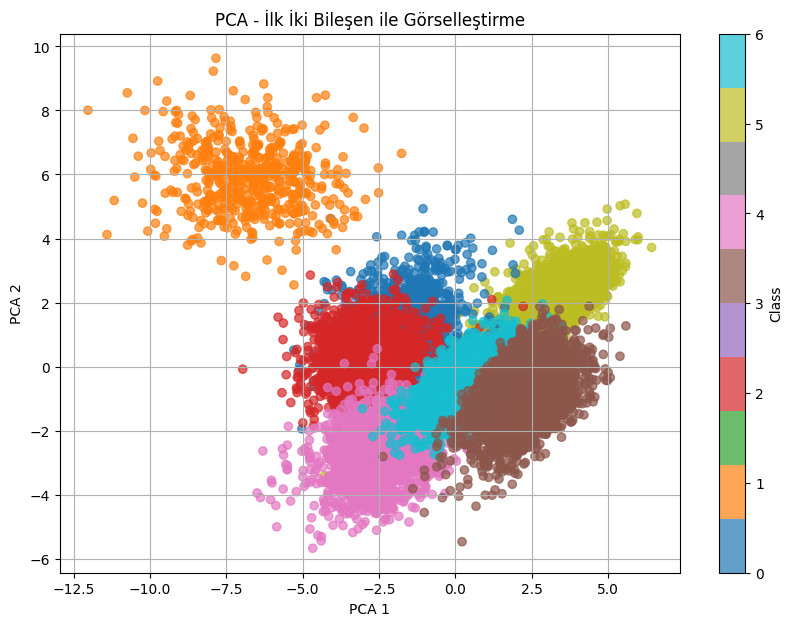

In [41]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('PCA - İlk İki Bileşen ile Görselleştirme')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Class')
plt.grid()
plt.show()

Explained Variance Ratios:

[0.525, 0.277, 0.084, 0.054, 0.029, 0.012, ...]

Ortalama: 0.0667



Bu da demek oluyor ki:

1. bileşen: %52.5 varyansı açıklıyor 

2. bileşen: %27.7 daha → toplam %80.2 oldu

3. bileşen: %8.4 → toplam %88.6’ya ulaşıyoruz

Ortalama üstünde olan bileşen sayısı = 3 

PCA 2D Görselleştirme Yorumu:

Scatter plot’ta class'lar oldukça iyi ayrışmış.

Bazı sınıflar biraz örtüşüyor ama çoğu net gruplar oluşturuyor.

Bu da PCA ile özellik ayrıştırması oldukça başarılı demek.

In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt

In [43]:
lda = LDA(n_components=3)


In [44]:
X_lda = lda.fit_transform(X, y)


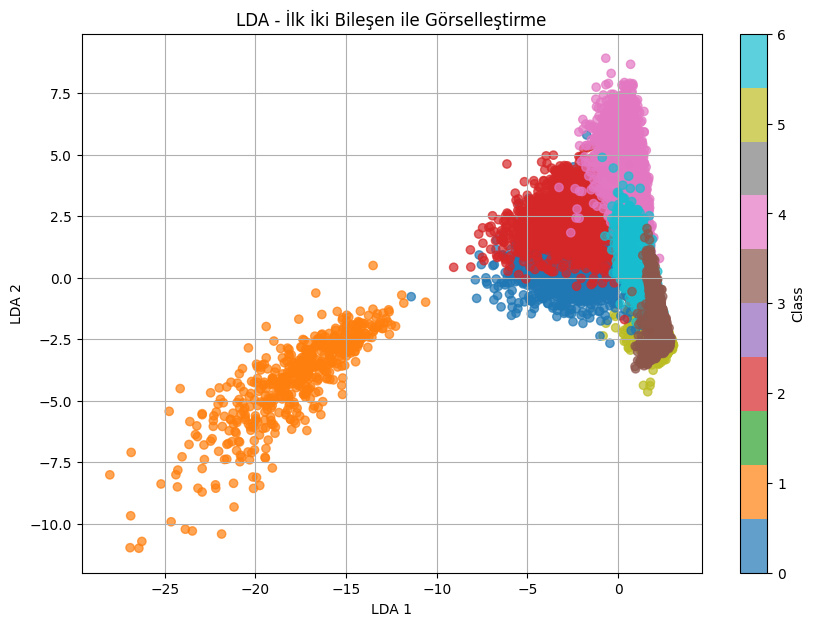

In [45]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('LDA - İlk İki Bileşen ile Görselleştirme')
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')
plt.colorbar(scatter, label='Class')
plt.grid()
plt.show()

Class 1 (turuncu) örnekleri diğer sınıflardan çok net ayrılmış 

Sağ tarafta diğer sınıflar arasında küçük örtüşmeler var ama genel ayrım oldukça başarılı.

Bu da LDA'nın sınıf etiketlerini kullanarak maksimum ayrım gücünü başarıyla uyguladığını gösteriyor.

# Bölüm 3: Modelleme ve Değerlendirme

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

X_base = X.copy()
y_base = y.copy()

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

outer_results = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_base, y_base):
    X_train, X_test = X_base.iloc[train_ix], X_base.iloc[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = LogisticRegression()
    clf = GridSearchCV(model, param_grid, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results:
    scores = outer_results[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.9186, Std=0.0077
PRECISION: Mean=0.9340, Std=0.0051
RECALL: Mean=0.9300, Std=0.0055
F1: Mean=0.9316, Std=0.0053


In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

outer_results_dt = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_base, y_base):
    X_train, X_test = X_base.iloc[train_ix], X_base.iloc[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = DecisionTreeClassifier(random_state=42)
    clf = GridSearchCV(model, param_grid, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_dt['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_dt['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_dt['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_dt['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_dt:
    scores = outer_results_dt[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.9065, Std=0.0049
PRECISION: Mean=0.9200, Std=0.0055
RECALL: Mean=0.9165, Std=0.0051
F1: Mean=0.9180, Std=0.0051


In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'criterion': ['gini', 'entropy']
}

outer_results_rf = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_base, y_base):
    X_train, X_test = X_base.iloc[train_ix], X_base.iloc[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = RandomForestClassifier(random_state=42)
    clf = GridSearchCV(model, param_grid, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_rf['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_rf['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_rf['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_rf['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_rf:
    scores = outer_results_rf[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")

ACCURACY: Mean=0.9252, Std=0.0031
PRECISION: Mean=0.9387, Std=0.0027
RECALL: Mean=0.9343, Std=0.0026
F1: Mean=0.9363, Std=0.0025


In [50]:
from warnings import filterwarnings
filterwarnings("ignore")

from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

outer_results_xgb = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_base, y_base):
    X_train, X_test = X_base.iloc[train_ix], X_base.iloc[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    clf = GridSearchCV(model, param_grid, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_xgb['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_xgb['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_xgb['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_xgb['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_xgb:
    scores = outer_results_xgb[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.9287, Std=0.0048
PRECISION: Mean=0.9420, Std=0.0031
RECALL: Mean=0.9391, Std=0.0028
F1: Mean=0.9404, Std=0.0029


In [51]:
from sklearn.naive_bayes import GaussianNB

outer_results_nb = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_base, y_base):
    X_train, X_test = X_base.iloc[train_ix], X_base.iloc[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    outer_results_nb['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_nb['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_nb['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_nb['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_nb:
    scores = outer_results_nb[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8994, Std=0.0076
PRECISION: Mean=0.9094, Std=0.0059
RECALL: Mean=0.9101, Std=0.0053
F1: Mean=0.9092, Std=0.0057


Ham veri üzerinde 5 model için Nested Cross-Validation tamamlandı 

Accuracy, Precision, Recall, F1 değerleri hesaplandı 

In [52]:
X_pca_final = X_pca[:, :3]

outer_results_pca_lr = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_pca_final, y_base):
    X_train, X_test = X_pca_final[train_ix], X_pca_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = LogisticRegression()
    clf = GridSearchCV(model, param_grid={'C': [0.1, 1, 10], 'solver': ['liblinear']}, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_pca_lr['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_pca_lr['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_pca_lr['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_pca_lr['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_pca_lr:
    scores = outer_results_pca_lr[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8271, Std=0.0044
PRECISION: Mean=0.8320, Std=0.0035
RECALL: Mean=0.8091, Std=0.0051
F1: Mean=0.8126, Std=0.0056


In [54]:
# PCA ile boyut indirgediğimiz için doğal olarak performans ham veriye göre düştü.

# Özellikle Recall biraz düştü → bu bazı sınıfları doğru yakalamakta biraz zorluk yaşadığını gösteriyor.

# Fakat yine de %82–%83 doğruluk seviyesi makul.

# PCA ile veri daha kompakt hale geldiği için hesaplama süresi ciddi şekilde azaldı.

In [55]:
X_pca_final = X_pca[:, :3]

outer_results_pca_dt = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_pca_final, y_base):
    X_train, X_test = X_pca_final[train_ix], X_pca_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = DecisionTreeClassifier(random_state=42)
    clf = GridSearchCV(model, param_grid={'max_depth': [5, 10, 20], 'criterion': ['gini', 'entropy']}, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_pca_dt['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_pca_dt['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_pca_dt['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_pca_dt['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_pca_dt:
    scores = outer_results_pca_dt[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8617, Std=0.0029
PRECISION: Mean=0.8654, Std=0.0023
RECALL: Mean=0.8596, Std=0.0020
F1: Mean=0.8614, Std=0.0016


PCA ile boyut indirgeme sonrası, Decision Tree modeli oldukça başarılı bir performans sergiledi.

Özellikle F1-score ve Recall değerlerinin yüksek olması, modelin sınıfları dengeli bir şekilde ayırt ettiğini gösteriyor.

Bu sonuçlar, PCA'nın Decision Tree ile uyumlu çalıştığını ve verinin önemli bilgilerini koruduğunu gösteriyor.



| Veri Temsili | Model              | Accuracy | F1-score |
|--------------|--------------------|----------|----------|
| Ham Veri     | Logistic Regression | 0.9186   | 0.9316   |
| Ham Veri     | Decision Tree       | 0.9065   | 0.9180   |
| Ham Veri     | Random Forest       | 0.9252   | 0.9363   |
| Ham Veri     | XGBoost             | 0.9287   | 0.9404   |
| Ham Veri     | GaussianNB          | 0.8994   | 0.9092   |
| PCA Verisi   | Logistic Regression | 0.8271   | 0.8126   |
| PCA Verisi   | Decision Tree       | 0.8617   | 0.8614   |

In [56]:
X_pca_final = X_pca[:, :3]

outer_results_pca_rf = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_pca_final, y_base):
    X_train, X_test = X_pca_final[train_ix], X_pca_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = RandomForestClassifier(random_state=42)
    clf = GridSearchCV(model, param_grid={
        'n_estimators': [50, 100],
        'max_depth': [5, 10, None]
    }, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_pca_rf['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_pca_rf['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_pca_rf['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_pca_rf['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_pca_rf:
    scores = outer_results_pca_rf[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8797, Std=0.0049
PRECISION: Mean=0.8836, Std=0.0050
RECALL: Mean=0.8765, Std=0.0043
F1: Mean=0.8783, Std=0.0043


| Veri Temsili | Model              | Accuracy | F1-score |
|--------------|--------------------|----------|----------|
| Ham Veri     | Logistic Regression | 0.9186   | 0.9316   |
| Ham Veri     | Decision Tree       | 0.9065   | 0.9180   |
| Ham Veri     | Random Forest       | 0.9252   | 0.9363   |
| Ham Veri     | XGBoost             | 0.9287   | 0.9404   |
| Ham Veri     | GaussianNB          | 0.8994   | 0.9092   |
| PCA Verisi   | Logistic Regression | 0.8271   | 0.8126   |
| PCA Verisi   | Decision Tree       | 0.8617   | 0.8614   |
| PCA Verisi   | Random Forest       | 0.8797   | 0.8783   |

In [57]:
X_pca_final = X_pca[:, :3]

outer_results_pca_xgb = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_pca_final, y_base):
    X_train, X_test = X_pca_final[train_ix], X_pca_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    clf = GridSearchCV(model, param_grid={
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1]
    }, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_pca_xgb['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_pca_xgb['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_pca_xgb['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_pca_xgb['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_pca_xgb:
    scores = outer_results_pca_xgb[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8822, Std=0.0075
PRECISION: Mean=0.8854, Std=0.0068
RECALL: Mean=0.8775, Std=0.0058
F1: Mean=0.8800, Std=0.0060


In [58]:
from sklearn.naive_bayes import GaussianNB

X_pca_final = X_pca[:, :3]

outer_results_pca_nb = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_pca_final, y_base):
    X_train, X_test = X_pca_final[train_ix], X_pca_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    outer_results_pca_nb['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_pca_nb['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_pca_nb['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_pca_nb['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_pca_nb:
    scores = outer_results_pca_nb[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8570, Std=0.0062
PRECISION: Mean=0.8646, Std=0.0049
RECALL: Mean=0.8569, Std=0.0053
F1: Mean=0.8577, Std=0.0054


| Veri Temsili | Model              | Accuracy | F1-score |
|--------------|--------------------|----------|----------|
| PCA Verisi   | Logistic Regression | 0.8271   | 0.8126   |
| PCA Verisi   | Decision Tree       | 0.8617   | 0.8614   |
| PCA Verisi   | Random Forest       | 0.8797   | 0.8783   |
| PCA Verisi   | XGBoost             | 0.8822   | 0.8800   |
| PCA Verisi   | GaussianNB          | 0.8570   | 0.8577   |

In [59]:
X_lda_final = X_lda

outer_results_lda_lr = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_lda_final, y_base):
    X_train, X_test = X_lda_final[train_ix], X_lda_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = LogisticRegression()
    clf = GridSearchCV(model, param_grid={'C': [0.1, 1, 10], 'solver': ['liblinear']}, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_lda_lr['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_lda_lr['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_lda_lr['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_lda_lr['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_lda_lr:
    scores = outer_results_lda_lr[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8591, Std=0.0056
PRECISION: Mean=0.8896, Std=0.0031
RECALL: Mean=0.8479, Std=0.0057
F1: Mean=0.8493, Std=0.0066


| Veri Temsili | Model              | Accuracy | F1-score |
|--------------|--------------------|----------|----------|
| LDA Verisi   | Logistic Regression | 0.8591   | 0.8493   |

In [60]:
X_lda_final = X_lda

outer_results_lda_dt = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_lda_final, y_base):
    X_train, X_test = X_lda_final[train_ix], X_lda_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = DecisionTreeClassifier(random_state=42)
    clf = GridSearchCV(model, param_grid={'max_depth': [5, 10, 20], 'criterion': ['gini', 'entropy']}, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_lda_dt['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_lda_dt['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_lda_dt['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_lda_dt['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_lda_dt:
    scores = outer_results_lda_dt[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8989, Std=0.0055
PRECISION: Mean=0.9129, Std=0.0050
RECALL: Mean=0.9108, Std=0.0049
F1: Mean=0.9116, Std=0.0050


| Veri Temsili | Model              | Accuracy | F1-score |
|--------------|--------------------|----------|----------|
| LDA Verisi   | Logistic Regression | 0.8591   | 0.8493   |
| LDA Verisi   | Decision Tree       | 0.8989   | 0.9116   |

In [61]:
X_lda_final = X_lda

outer_results_lda_rf = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_lda_final, y_base):
    X_train, X_test = X_lda_final[train_ix], X_lda_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = RandomForestClassifier(random_state=42)
    clf = GridSearchCV(model, param_grid={
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'criterion': ['gini', 'entropy']
    }, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_lda_rf['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_lda_rf['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_lda_rf['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_lda_rf['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_lda_rf:
    scores = outer_results_lda_rf[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.9131, Std=0.0055
PRECISION: Mean=0.9283, Std=0.0041
RECALL: Mean=0.9225, Std=0.0055
F1: Mean=0.9250, Std=0.0049


In [62]:
from xgboost import XGBClassifier

X_lda_final = X_lda

outer_results_lda_xgb = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_lda_final, y_base):
    X_train, X_test = X_lda_final[train_ix], X_lda_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    clf = GridSearchCV(model, param_grid={
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1]
    }, cv=inner_cv, scoring='accuracy')
    clf.fit(X_train, y_train)

    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)

    outer_results_lda_xgb['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_lda_xgb['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_lda_xgb['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_lda_xgb['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_lda_xgb:
    scores = outer_results_lda_xgb[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.9154, Std=0.0063
PRECISION: Mean=0.9303, Std=0.0046
RECALL: Mean=0.9249, Std=0.0057
F1: Mean=0.9273, Std=0.0052


In [63]:
from sklearn.naive_bayes import GaussianNB

X_lda_final = X_lda

outer_results_lda_nb = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for train_ix, test_ix in outer_cv.split(X_lda_final, y_base):
    X_train, X_test = X_lda_final[train_ix], X_lda_final[test_ix]
    y_train, y_test = y_base.iloc[train_ix], y_base.iloc[test_ix]

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    outer_results_lda_nb['accuracy'].append(accuracy_score(y_test, y_pred))
    outer_results_lda_nb['precision'].append(precision_score(y_test, y_pred, average='macro'))
    outer_results_lda_nb['recall'].append(recall_score(y_test, y_pred, average='macro'))
    outer_results_lda_nb['f1'].append(f1_score(y_test, y_pred, average='macro'))

for metric in outer_results_lda_nb:
    scores = outer_results_lda_nb[metric]
    print(f"{metric.upper()}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")


ACCURACY: Mean=0.8842, Std=0.0065
PRECISION: Mean=0.8982, Std=0.0032
RECALL: Mean=0.8871, Std=0.0055
F1: Mean=0.8900, Std=0.0050


| Veri Temsili | Model              | Accuracy | F1-score |
|--------------|--------------------|----------|----------|
| LDA Verisi   | Logistic Regression | 0.8591   | 0.8493   |
| LDA Verisi   | Decision Tree       | 0.8989   | 0.9116   |
| LDA Verisi   | Random Forest       | 0.9131   | 0.9250   |
| LDA Verisi   | XGBoost             | 0.9154   | 0.9273   |
| LDA Verisi   | GaussianNB          | 0.8842   | 0.8900   |

| Veri Temsili | Model              | Accuracy | F1-score |
|--------------|--------------------|----------|----------|
| Ham Veri     | Logistic Regression | 0.9186   | 0.9316   |
| Ham Veri     | Decision Tree       | 0.9065   | 0.9180   |
| Ham Veri     | Random Forest       | 0.9252   | 0.9363   |
| Ham Veri     | XGBoost             | 0.9287   | 0.9404   |
| Ham Veri     | GaussianNB          | 0.8994   | 0.9092   |
| PCA Verisi   | Logistic Regression | 0.8271   | 0.8126   |
| PCA Verisi   | Decision Tree       | 0.8617   | 0.8614   |
| PCA Verisi   | Random Forest       | 0.8797   | 0.8783   |
| PCA Verisi   | XGBoost             | 0.8822   | 0.8800   |
| PCA Verisi   | GaussianNB          | 0.8570   | 0.8577   |
| LDA Verisi   | Logistic Regression | 0.8591   | 0.8493   |
| LDA Verisi   | Decision Tree       | 0.8989   | 0.9116   |
| LDA Verisi   | Random Forest       | 0.9131   | 0.9250   |
| LDA Verisi   | XGBoost             | 0.9154   | 0.9273   |
| LDA Verisi   | GaussianNB          | 0.8842   | 0.8900   |

Ham veride XGBoost en iyi modeli verdi.

PCA'da genel başarı düştü ama XGBoost ve Random Forest iyi korudu.

LDA'da XGBoost ve Random Forest yine en iyi sonuçları verdi.

Ham veri kullanılarak elde edilen XGBoost modeli en yüksek doğruluğa ve F1 skoruna ulaşmıştır.
LDA dönüşümü ile XGBoost ve Random Forest modelleri, boyut indirgeme sonrası performansı en az kayıp ile koruyan modeller olmuştur.

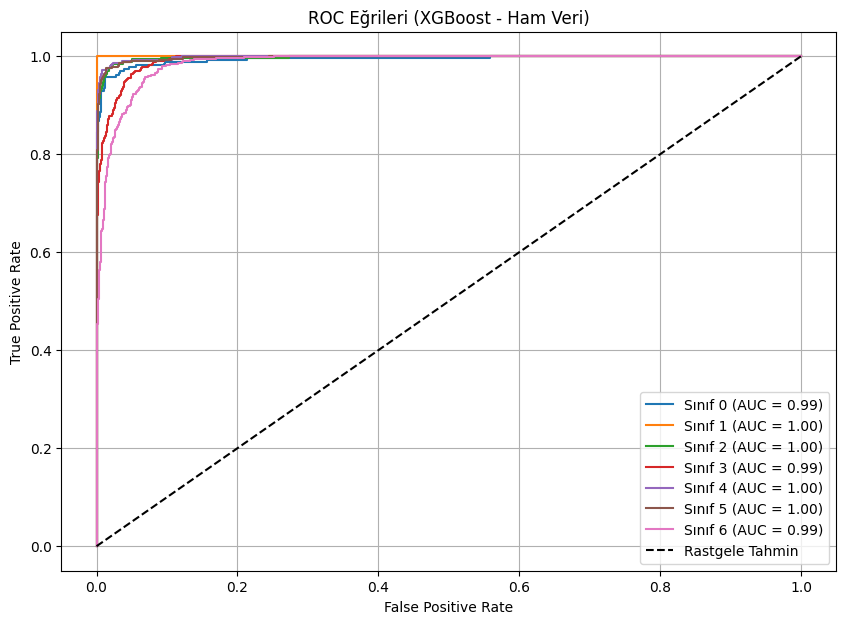

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

# 1. XGBoost en iyi modeli tekrar eğit (final veriyle)
X_train, X_test, y_train, y_test = train_test_split(X_base, y_base, test_size=0.2, stratify=y_base, random_state=42)

best_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42,
                           n_estimators=200, max_depth=5, learning_rate=0.1)
best_model.fit(X_train, y_train)

# 2. Gerçek etiketleri binarize et (One-vs-All için)
n_classes = len(np.unique(y_base))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# 3. Tahmin olasılıkları al
y_score = best_model.predict_proba(X_test)

# 4. ROC eğrilerini çiz
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

# 5. Grafik çizimi
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Sınıf {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrileri (XGBoost - Ham Veri)")
plt.legend(loc='lower right')
plt.grid()
plt.show()


| Sınıf | AUC Skoru |
|-------|-----------|
| 0     | 0.99      |
| 1     | 1.00      |
| 2     | 1.00      |
| 3     | 0.99      |
| 4     | 1.00      |
| 5     | 1.00      |
| 6     | 0.99      |

Eğrilerin neredeyse tamamı sol üst köşeye çok yakın → model sınıfları çok iyi ayırt edebiliyor.

Rastgele tahmin çizgisi ile eğriler arasındaki fark maksimum ayrım başarısı gösteriyor.

7 sınıfın hepsinde AUC ≥ 0.99 ve bazıları 1.00 → bu, olağanüstü bir genel sınıflandırma performansıdır.

